In [ ]:
!pip install kagglehub

import kagglehub

# Download the latest version of the CCSN dataset
path = kagglehub.dataset_download("mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database")

print("Path to dataset files:", path)

100%|██████████| 93.2M/93.2M [00:03<00:00, 27.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database/versions/1


In [ ]:
import os
import shutil

# 1. Look directly inside the kagglehub version 1 folder
download_base = '/root/.cache/kagglehub/datasets/mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database/versions/1'

# Search all subdirectories to find where the actual cloud folders (like Ci, Cs) live
source_dir = None
for root, dirs, files in os.walk(download_base):
    if any(c in dirs for c in ['Ci', 'Cs', 'Cc', 'Ac']):
        source_dir = root
        break

if not source_dir:
    raise FileNotFoundError("Could not find cloud data folders. Please re-run Step 2 to ensure the download finished.")

print(f"Found dataset source directory at: {source_dir}")

# 2. Define our 3 new target rainfall classes
base_target_dir = './rainfall_dataset'
classes = ['No_to_Low_Rain', 'Low_to_Medium_Rain', 'Medium_to_Heavy_Rain']

# Clear previous setups to start fresh
if os.path.exists(base_target_dir):
    shutil.rmtree(base_target_dir)

for c in classes:
    os.makedirs(os.path.join(base_target_dir, c), exist_ok=True)

# 3. Define the scientific mapping from the research paper
mapping = {
    'No_to_Low_Rain': ['Ci', 'Cs', 'Cc', 'Ac'],
    'Low_to_Medium_Rain': ['As', 'Sc', 'St', 'Ns'],
    'Medium_to_Heavy_Rain': ['Cb', 'Cu', 'Ct']
}

# 4. Move files into their respective target rainfall directories
copied_count = 0
for rainfall_class, cloud_folders in mapping.items():
    for folder in cloud_folders:
        folder_path = os.path.join(source_dir, folder)
        if os.path.exists(folder_path):
            for filename in os.listdir(folder_path):
                src_file = os.path.join(folder_path, filename)
                dst_file = os.path.join(base_target_dir, rainfall_class, f"{folder}_{filename}")
                shutil.copy(src_file, dst_file)
                copied_count += 1

print(f"Success! {copied_count} images successfully sorted into 3 rainfall categories.")

Found dataset source directory at: /root/.cache/kagglehub/datasets/mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database/versions/1/CCSN_v2
Success! 2543 images successfully sorted into 3 rainfall categories.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize data generator with data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizes image pixel values between 0 and 1
    rotation_range=25,        # Randomly rotates images up to 25 degrees
    width_shift_range=0.2,    # Randomly shifts images horizontally
    height_shift_range=0.2,   # Randomly shifts images vertically
    horizontal_flip=True,     # Randomly flips images horizontally
    validation_split=0.2      # Set aside 20% of the dataset for testing/validation
)

# Load Training Images (80% of data)
train_generator = train_datagen.flow_from_directory(
    base_target_dir,
    target_size=(256, 256),   # Xception's optimal size
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Load Validation Images (20% of data)
validation_generator = train_datagen.flow_from_directory(
    base_target_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2036 images belonging to 3 classes.
Found 507 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 1. Load Xception with pre-trained ImageNet weights, omitting its original top layer
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# 2. Freeze the base model to preserve learned weights during phase 1 training
base_model.trainable = False

# 3. Add custom classification layers for our specific rainfall classes
x = base_model.output
x = GlobalAveragePooling2D()(x) # flattens the multidimensional features
x = Dropout(0.4)(x)             # Prevents overfitting by randomly turning off nodes
predictions = Dense(3, activation='softmax')(x) # 3 outputs for our 3 rainfall classes

# 4. Tie everything together into a final model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 127, 127,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 127, 127,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 127, 127,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 125, 125,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 125, 125,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 125, 125,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 125, 125,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 125, 125,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 125, 125,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 125, 125,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 125, 125,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 63, 63,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 63, 63,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 63, 63,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 63, 63,    │          0 │ add_12[0][0]    

 Total params: 20,867,627 (79.60 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
print("Starting Phase 1 Training...")
history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50
)

Starting Phase 1 Training...
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.5118 - loss: 0.9880 - val_accuracy: 0.4951 - val_loss: 1.0254
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 741ms/step - accuracy: 0.5928 - loss: 0.8864 - val_accuracy: 0.5089 - val_loss: 0.9632
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 750ms/step - accuracy: 0.6027 - loss: 0.8571 - val_accuracy: 0.5345 - val_loss: 0.9510
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 713ms/step - accuracy: 0.6380 - loss: 0.8323 - val_accuracy: 0.5089 - val_loss: 0.9646
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 740ms/step - accuracy: 0.6395 - loss: 0.8267 - val_accuracy: 0.5365 - val_loss: 0.9515
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 741ms/step - accuracy: 0.6508 - loss: 0.8047 - val_accuracy: 0.5306 - val_loss: 0.9471
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 714ms/step - accuracy: 0.6473 - loss: 0.7985 - val_accuracy: 0.5562 - val_loss: 0.9407
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 731ms/step - accuracy: 0.657

In [ ]:
print("Unfreezing layers for Fine-Tuning...")
base_model.trainable = True

# Re-compile with an incredibly small learning rate so we don't destroy pre-learned shapes
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Phase 2 Fine-Tuning...")
history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50
)

# Save your fully trained model file to your drive
model.save("xception_rainfall_model.h5")
print("Model saved as xception_rainfall_model.h5")

Unfreezing layers for Fine-Tuning...
Starting Phase 2 Fine-Tuning...
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.4258 - loss: 1.0653 - val_accuracy: 0.4103 - val_loss: 1.0779
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 990ms/step - accuracy: 0.5653 - loss: 0.9601 - val_accuracy: 0.4714 - val_loss: 1.0075
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 991ms/step - accuracy: 0.6410 - loss: 0.8646 - val_accuracy: 0.5464 - val_loss: 0.9346
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 974ms/step - accuracy: 0.6803 - loss: 0.7810 - val_accuracy: 0.5404 - val_loss: 0.9257
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 982ms/step - accuracy: 0.7313 - loss: 0.7081 - val_accuracy: 0.5562 - val_loss: 0.9019
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 982ms/step - accuracy: 0.7362 - loss: 0.6654 - val_accuracy: 0.5917 - val_loss: 0.8947
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 981ms/step - accuracy: 0.7475 - loss: 0.6276 - val_accuracy: 0.5740 - val_loss: 0.8880
Epoch 8/50
64/64 ━━━━━━━━━━━━━

Model saved as xception_rainfall_model.h5


Saving Screenshot 2026-07-15 213235.png to Screenshot 2026-07-15 213235.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step

      CLOUD ANALYSIS & RAINFALL PREDICTION REPORT
Predicted Status : Low to Medium Rain
Confidence Level : 72.15%
--------------------------------------------------
Meteorological Context: Extensive layered gray clouds detected (e.g., Stratus/Nimbostratus).
Rain Probability      : 40% - 75%
Advisory Action       : Drizzle or steady moderate rain expected. Postpone open-air treatments.



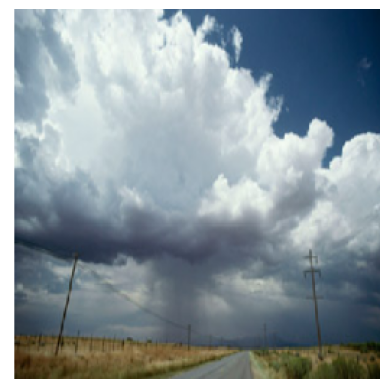

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files  # <-- This line fixes the error!

def predict_local_weather(img_path):
    # 1. Load and process the image to match model input parameters
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # 2. Run the prediction
    predictions = model.predict(img_array)[0]
    classes = ["No Rain to Very Low Rain", "Low to Medium Rain", "Medium to Heavy/High Rain"]
    predicted_idx = np.argmax(predictions)
    confidence = predictions[predicted_idx] * 100

    # 3. Print the formatted Report
    print("\n" + "="*50)
    print("      CLOUD ANALYSIS & RAINFALL PREDICTION REPORT")
    print("="*50)
    print(f"Predicted Status : {classes[predicted_idx]}")
    print(f"Confidence Level : {confidence:.2f}%")
    print("-"*50)

    if predicted_idx == 0:
        print("Meteorological Context: High/mid-level wispy or patchy clouds detected (e.g., Cirrus/Altocumulus).")
        print("Rain Probability      : < 15%")
        print("Advisory Action       : Safe to proceed with normal outdoor planning and agricultural irrigation.")
    elif predicted_idx == 1:
        print("Meteorological Context: Extensive layered gray clouds detected (e.g., Stratus/Nimbostratus).")
        print("Rain Probability      : 40% - 75%")
        print("Advisory Action       : Drizzle or steady moderate rain expected. Postpone open-air treatments.")
    elif predicted_idx == 2:
        print("Meteorological Context: Dense, vertically developed storm clouds detected (e.g., Cumulonimbus).")
        print("Rain Probability      : > 85%")
        print("Advisory Action       : High risk of heavy downpours or thunderstorms. Secure sensitive field assets immediately.")
    print("="*50 + "\n")

    # Display the uploaded image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Trigger an upload prompt to test a new image
uploaded = files.upload()
for fn in uploaded.keys():
    predict_local_weather(fn)

In [ ]:
# Save the model using the native Keras format
model.save('xception_rainfall_model.keras')

# Download the updated file
from google.colab import files
files.download('xception_rainfall_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img

# 1. Load your trained model
# Make sure you have already run model.save('xception_rainfall_model.keras')
model = tf.keras.models.load_model('xception_rainfall_model.keras')

# 2. Define the exact class labels matching your generator
class_names = ['No_to_Low_Rain', 'Low_to_Medium_Rain', 'Medium_to_Heavy_Rain']

# 3. Define the prediction function
def predict_rainfall(image):
    if image is None:
        return "Please upload an image."

    # Resize image to match Xception input size (256x256)
    img = image.resize((256, 256))
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make prediction
    predictions = model.predict(img_array)[0]

    # Return as a dictionary of label -> probability for Gradio's Label component
    return {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

# 4. Design a clean, modern interface using Gradio Blocks
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 🌧️ Cloud Analysis & Rainfall Predictor
        Upload an image of the sky/clouds below to analyze their meteorological characteristics and predict potential rainfall levels using your trained Xception model.
        """
    )

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Cloud Image")
            submit_btn = gr.Button("Analyze Sky", variant="primary")

        with gr.Column():
            label_output = gr.Label(num_top_classes=3, label="Rainfall Probability")

    # Connect the input image and button to the predictor
    submit_btn.click(
        fn=predict_rainfall,
        inputs=image_input,
        outputs=label_output
    )

# 5. Launch the interface
# setting share=True generates a temporary public link you can send to others
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/tmp/ipykernel_2039/690206901.py:31: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2be562d185968daaed.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# 1. Load your trained model
# Ensure you saved your model in Colab using: model.save('cloud_rain_model.h5')
model = tf.keras.models.load_model('cloud_rain_model.h5')

# Define the exact class names in alphabetical order matching ImageDataGenerator
class_names = ['Low_to_Medium_Rain', 'Medium_to_Heavy_Rain', 'No_to_Low_Rain']

# Color scheme for the overlay UI (BGR format)
class_colors = {
    'No_to_Low_Rain': (0, 255, 0),        # Green
    'Low_to_Medium_Rain': (0, 255, 255),  # Yellow
    'Medium_to_Heavy_Rain': (0, 0, 255)   # Red
}

# 2. Open Webcam (0 for default camera)
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Flip frame horizontally for a intuitive selfie-view
    frame = cv2.flip(frame, 1)

    # 3. Preprocess frame for the model (256x256 as used in Xception)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized_frame = cv2.resize(rgb_frame, (256, 256))
    normalized_frame = resized_frame / 255.0
    input_tensor = np.expand_dims(normalized_frame, axis=0)

    # 4. Predict
    predictions = model.predict(input_tensor, verbose=0)[0]
    class_idx = np.argmax(predictions)
    predicted_label = class_names[class_idx]
    confidence = predictions[class_idx] * 100

    # 5. Draw OpenCV UI Overlay
    height, width, _ = frame.shape
    accent_color = class_colors[predicted_label]

    # Semi-transparent top bar for UI Header
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (width, 90), (30, 30, 30), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    # Status Text Overlay
    cv2.putText(frame, f"Prediction: {predicted_label}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, accent_color, 2, cv2.LINE_AA)

    cv2.putText(frame, f"Confidence: {confidence:.2f}%", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)

    # Display status bar for each class on the left side
    y_offset = 130
    for i, name in enumerate(class_names):
        score = predictions[i] * 100
        # Label
        cv2.putText(frame, f"{name}:", (20, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 220, 220), 1, cv2.LINE_AA)

        # Confidence progress bar
        bar_width = int(score * 1.5)  # Scale width
        cv2.rectangle(frame, (180, y_offset - 10), (180 + bar_width, y_offset + 2), class_colors[name], -1)
        cv2.rectangle(frame, (180, y_offset - 10), (180 + 150, y_offset + 2), (100, 100, 100), 1)

        y_offset += 30

    # Show final frame
    cv2.imshow("Cloud Recognition & Rain Prediction UI", frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'cloud_rain_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
model.save('cloud_rain_model.h5')